Predictions equal: True
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

[[940  95]
 [177 197]]


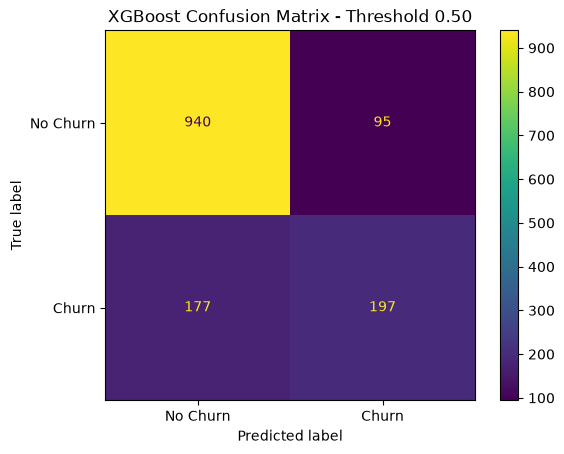

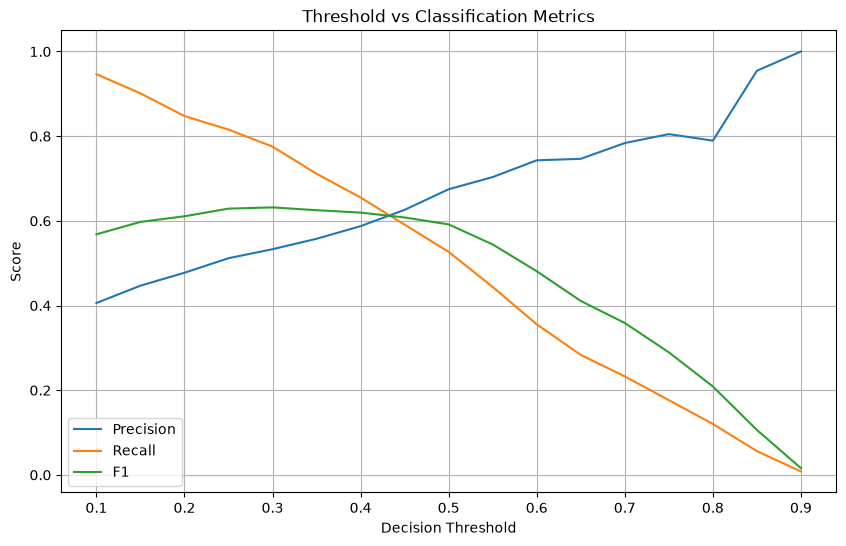

Best F1 threshold: 0.30000000000000004


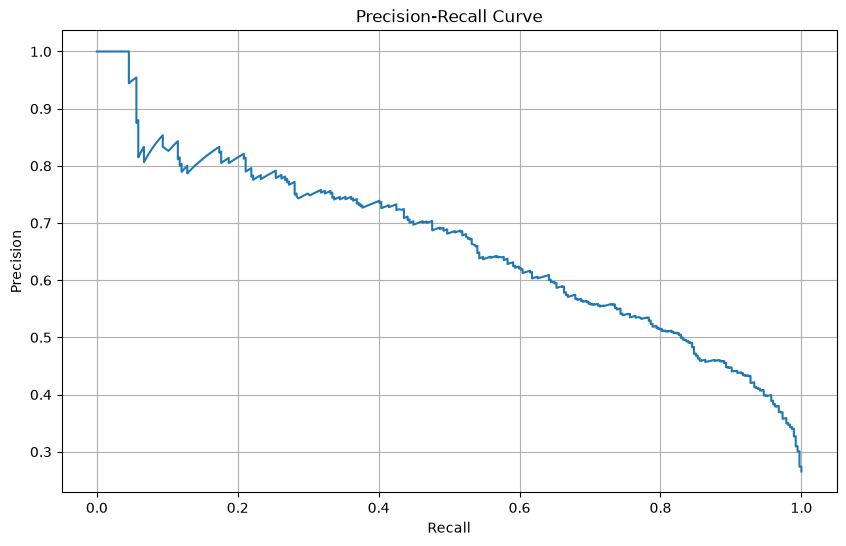

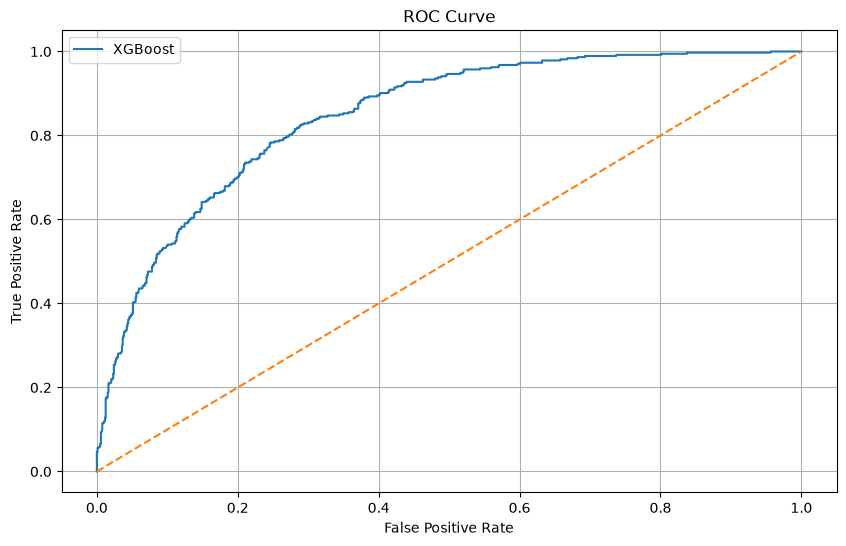

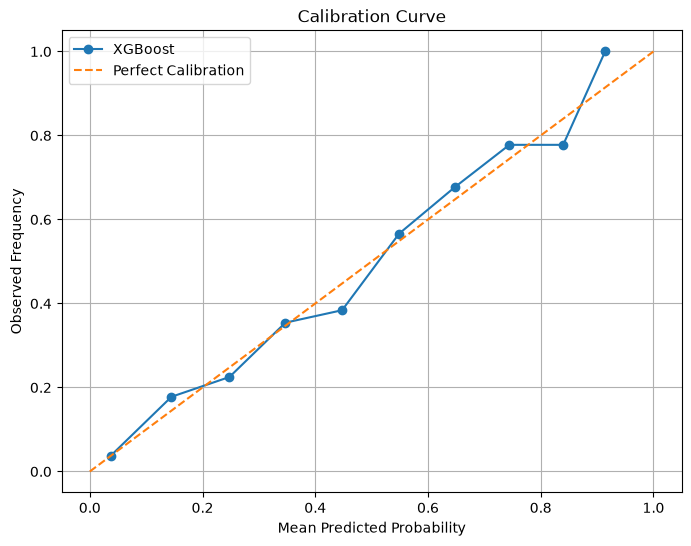

In [7]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
best_logistic = joblib.load(
    "../models/logistic_regression_tuned.joblib"
)

best_rf = joblib.load(
    "../models/random_forest_tuned.joblib"
)

best_xgb = joblib.load(
    "../models/xgboost_tuned.joblib"
)
xgb_probabilities = best_xgb.predict_proba(
    X_test
)[:, 1]
xgb_probabilities[:20]

threshold = 0.50

y_pred_05 = (
    xgb_probabilities >= threshold
).astype(int)

print(
    "Predictions equal:",
    np.array_equal(
        y_pred_05,
        best_xgb.predict(X_test)
    )
)

print(
    classification_report(
        y_test,
        y_pred_05,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

metrics_05 = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_05
    ),

    "Precision": precision_score(
        y_test,
        y_pred_05,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_05,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        y_pred_05,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        xgb_probabilities
    ),

    "PR-AUC": average_precision_score(
        y_test,
        xgb_probabilities
    )
}

metrics_05

cm = confusion_matrix(
    y_test,
    y_pred_05
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

disp.plot()
plt.title("XGBoost Confusion Matrix - Threshold 0.50")
plt.show()

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_pred = (
        xgb_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.legend()
plt.grid(True)

plt.show()

best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f1_row

best_f1_threshold = best_f1_row["Threshold"]

print(
    "Best F1 threshold:",
    best_f1_threshold
)

fine_thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

fine_results = []

for threshold in fine_thresholds:

    y_pred = (
        xgb_probabilities >= threshold
    ).astype(int)

    fine_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

fine_threshold_df = pd.DataFrame(
    fine_results
)

best_f1_row = fine_threshold_df.loc[
    fine_threshold_df["F1"].idxmax()
]

best_f1_row

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    xgb_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.show()

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    xgb_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

FN_COST = 1000
FP_COST = 100

business_results = []

for threshold in fine_thresholds:

    y_pred = (
        xgb_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    cost = (
        fp * FP_COST
        +
        fn * FN_COST
    )

    business_results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "Business_Cost": cost
    })

business_df = pd.DataFrame(
    business_results
)

business_df.loc[
    business_df["Business_Cost"].idxmin()
]


recall_constraint = fine_threshold_df[
    fine_threshold_df["Recall"] >= 0.80
]

recall_constraint

best_under_recall_constraint = recall_constraint.loc[
    recall_constraint["Precision"].idxmax()
]

best_under_recall_constraint

model_probabilities = {
    "Logistic Regression": best_logistic.predict_proba(
        X_test
    )[:, 1],

    "Random Forest": best_rf.predict_proba(
        X_test
    )[:, 1],

    "XGBoost": best_xgb.predict_proba(
        X_test
    )[:, 1]
}

model_threshold_results = []

for name, probabilities in model_probabilities.items():

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    model_threshold_results.append({
        "Model": name,

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),

        "PR-AUC": average_precision_score(
            y_test,
            probabilities
        )
    })

model_threshold_df = pd.DataFrame(
    model_threshold_results
)

model_threshold_df

from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_probabilities,
    n_bins=10
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()